# **Data Preparation**

In [30]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Load the files (adjust paths if needed)
pokemon_path = Path("pokemon.csv")      # e.g., '/content/pokemon.csv'
combats_path = Path("combats.csv")      # e.g., '/content/combats.csv'

pokemon = pd.read_csv(pokemon_path)
combats = pd.read_csv(combats_path)

print("pokemon shape:", pokemon.shape)
print("combats shape:", combats.shape)
print(pokemon.head(3))
print(combats.head(3))

# Basic cleanup / column normalisation (common columns)
# Ensure the ID column exists and is consistently named '#'
if '#' not in pokemon.columns:
    # some versions use 'Number' or 'id'
    for cand in ['Number', 'id', 'ID', 'pokemonId']:
        if cand in pokemon.columns:
            pokemon.rename(columns={cand: '#'}, inplace=True)
            break

# standardise type columns if needed
if 'Type 1' not in pokemon.columns and 'type1' in pokemon.columns:
    pokemon.rename(columns={'type1': 'Type 1'}, inplace=True)
if 'Type 2' not in pokemon.columns and 'type2' in pokemon.columns:
    pokemon.rename(columns={'type2': 'Type 2'}, inplace=True)

# Fix missing values
# Fill missing Name for Pokémon #62 with 'Primeape' (as required by your brief)
mask_62_missing = (pokemon['#'] == 62) & (pokemon['Name'].isna() | (pokemon['Name'].astype(str).str.strip() == ''))
if mask_62_missing.any():
    pokemon.loc[mask_62_missing, 'Name'] = 'Primeape'

# Fill missing Type 2 with a string 'None' (so it stays categorical)
if 'Type 2' in pokemon.columns:
    pokemon['Type 2'] = pokemon['Type 2'].fillna('None')

# If any other numeric NaNs exist in stats, fill with median
numeric_cols = pokemon.select_dtypes(include='number').columns.tolist()
pokemon[numeric_cols] = pokemon[numeric_cols].fillna(pokemon[numeric_cols].median())

# Compute win counts, battle counts, and win percentage from combats
# combats columns are typically: 'First_pokemon', 'Second_pokemon', 'Winner' (all IDs referencing '#')
# Count wins
wins = combats['Winner'].value_counts().rename('wins')

# Count total battles per Pokémon: appeared as first OR second
appears_first = combats['First_pokemon'].value_counts()
appears_second = combats['Second_pokemon'].value_counts()
battles = (appears_first.add(appears_second, fill_value=0)).rename('battles')

# Combine into one DataFrame keyed by Pokémon ID
performance = pd.concat([wins, battles], axis=1).fillna(0).astype(int).reset_index()
performance.rename(columns={'index': '#'}, inplace=True)
performance['win_pct'] = (performance['wins'] / performance['battles']).fillna(0) * 100

# Merge performance back onto pokemon stats
df = pokemon.merge(performance, on='#', how='left')
df[['wins','battles','win_pct']] = df[['wins','battles','win_pct']].fillna(0)

# Quick sanity checks
print("\nMissing values per column:\n", df.isna().sum().sort_values(ascending=False).head(10))
print("\nSample rows with performance columns:\n",
      df[['#','Name','Type 1','Type 2','wins','battles','win_pct']].head(10))

# Final tidy frame for later modeling (keep core stats + target)
# Adjust these stat column names to match your file if needed:
stat_cols = [c for c in ['HP','Attack','Defense','Sp. Atk','Sp. Def','Speed'] if c in df.columns]
keep_cols = ['#','Name','Type 1','Type 2','wins','battles','win_pct'] + stat_cols
df_final = df[keep_cols].copy()

print("\nFinal modeling frame shape:", df_final.shape)
df_final.head()

pokemon shape: (800, 12)
combats shape: (50000, 3)
   #       Name Type 1  Type 2  HP  Attack  Defense  Sp. Atk  Sp. Def  Speed  \
0  1  Bulbasaur  Grass  Poison  45      49       49       65       65     45   
1  2    Ivysaur  Grass  Poison  60      62       63       80       80     60   
2  3   Venusaur  Grass  Poison  80      82       83      100      100     80   

   Generation  Legendary  
0           1      False  
1           1      False  
2           1      False  
   First_pokemon  Second_pokemon  Winner
0            266             298     298
1            702             701     701
2            191             668     668

Missing values per column:
 Name       1
#          0
Type 1     0
Type 2     0
HP         0
Attack     0
Defense    0
Sp. Atk    0
Sp. Def    0
Speed      0
dtype: int64

Sample rows with performance columns:
     #              Name Type 1  Type 2   wins  battles    win_pct
0   1         Bulbasaur  Grass  Poison   37.0    133.0  27.819549
1   2       

,#,Name,Type 1,Type 2,wins,battles,win_pct,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
0,1,Bulbasaur,Grass,Poison,37.0,133.0,27.819549,45,49,49,65,65,45
1,2,Ivysaur,Grass,Poison,46.0,121.0,38.016529,60,62,63,80,80,60
2,3,Venusaur,Grass,Poison,89.0,132.0,67.424242,80,82,83,100,100,80
3,4,Mega Venusaur,Grass,Poison,70.0,125.0,56.000000,80,100,123,122,120,80
4,5,Charmander,Fire,None,55.0,112.0,49.107143,39,52,43,60,50,65


# **Exploratory Analysis & Visualization**

In [31]:
# Creating the Win Percentage column

# Total battles (each Pokémon can appear in either column)
total_battles = combats['First_pokemon'].value_counts() + combats['Second_pokemon'].value_counts()

# Total wins for each Pokémon
wins = combats['Winner'].value_counts()

# Compute win percentage (wins / total battles * 100)
pokemon['Win_Percentage'] = (wins / total_battles) * 100

# Fill NaN (Pokémon who never fought)
pokemon['Win_Percentage'] = pokemon['Win_Percentage'].fillna(0)

In [32]:
pokemon[['#', 'Name', 'Win_Percentage']].head(10)

,#,Name,Win_Percentage
0,1,Bulbasaur,0.000000
1,2,Ivysaur,27.819549
2,3,Venusaur,38.016529
3,4,Mega Venusaur,67.424242
4,5,Charmander,56.000000
5,6,Charmeleon,49.107143
6,7,Charizard,54.237288
7,8,Mega Charizard X,86.466165
8,9,Mega Charizard Y,85.611511
9,10,Squirtle,84.444444


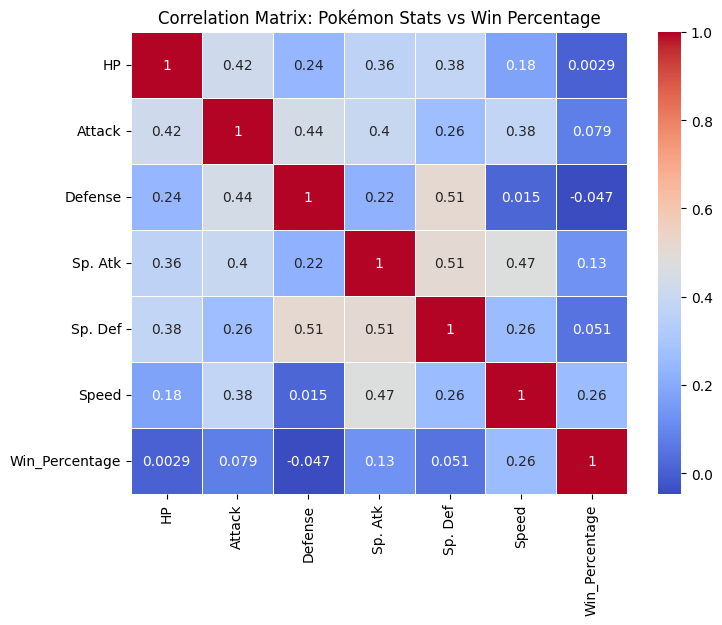

In [33]:
# Correlation Matrix

# Select only numeric columns and include 'Win_Percentage'
numeric_cols = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Win_Percentage']

# Compute the correlation matrix
corr_matrix = pokemon[numeric_cols].corr()

# Plot the heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix: Pokémon Stats vs Win Percentage')
plt.show()

In [ ]:
# Pairplot (Visual Relationships)
sns.pairplot(pokemon[numeric_cols], diag_kind='kde')
plt.suptitle('Pairwise Relationships Between Stats and Win Percentage', y=1.02)
plt.show()

In [ ]:
# Top 10 Pokémon by Win Percentage
top_10 = pokemon.sort_values(by='Win_Percentage', ascending=False).head(10)
print(top_10[['Name', 'HP', 'Attack', 'Defense', 'Speed', 'Win_Percentage']])

plt.figure(figsize=(10,5))
sns.barplot(data=top_10, x='Name', y='Win_Percentage', palette='viridis')
plt.title('Top 10 Pokémon by Win Percentage')
plt.xticks(rotation=45)
plt.show()


# **Machine Learning**

In [ ]:
# Preapre the freature (X) and (y)

# Features (independent variables)
X = pokemon[['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']]

# Target (dependent variable)
y = pokemon['Win_Percentage']

# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

In [ ]:
# Scaling Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Training Linear Regression
lin_model = LinearRegression()
lin_model.fit(X_train_scaled, y_train)

lin_preds = lin_model.predict(X_test_scaled)
lin_mae = mean_absolute_error(y_test, lin_preds)
print("Linear Regression MAE:", round(lin_mae, 4))

In [ ]:
# Training Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_preds)
print("Random Forest MAE:", round(rf_mae, 4))

In [ ]:
# Training XGBoost Regressor
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
xgb_mae = mean_absolute_error(y_test, xgb_preds)
print("XGBoost MAE:", round(xgb_mae, 4))

In [ ]:
# Comparing all models
print("\nMODEL PERFORMANCE COMPARISON")
print(f"Linear Regression MAE: {lin_mae:.4f}")
print(f"Random Forest MAE:     {rf_mae:.4f}")
print(f"XGBoost MAE:           {xgb_mae:.4f}")